# USGS Terremotos Análsie (2020 - 2026)
*Fonte dos Dados:* API REST GeoJSON do USGS (United States Geological Survey)

---

> ### 1. O Que Estes Dados Realmente Mostram? (Data Storytelling)
> 
> Em palavras simples, a análise revela **como a Terra libera energia e onde o risco de desastres está concentrado**:
> 
> 1. **O Perigo da Superfície (Fator Proximidade):** Um terremoto não precisa ser o maior do mundo para ser devastador. Maioria dos sismos são rasos (**< 70 km)**, ocorrendo perto das cidades, o que impede a dissipação de energia.
> 2. **A Sismicidade:** A Terra treme com a mesma frequência de dia e de noite (**~4,16%** de eventos por hora nas 24h do dia). Não existem "horários de pico" ou estações do ano para terremotos.
> 3. **Localização Geográfica:** O risco não é distribuído aleatoriamente no planeta. Mais de **70%** de todos os grandes sismos (**$M \ge 5.0$**) estão concentrados em uma única região tectônica: o **Anel de Fogo do Pacífico**.

---


---
## 1. Carga e Configuração

Import das bibliotecas


In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import time
import re
import os
import csv

warnings.filterwarnings('ignore')

# Estilo Visual
plt.style.use('dark_background')
plt.rcParams['font.sans-serif'] = 'Inter, Segoe UI, Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.facecolor'] = '#0F172A'
plt.rcParams['axes.facecolor'] = '#1E293B'
plt.rcParams['axes.edgecolor'] = '#334155'
plt.rcParams['axes.labelcolor'] = '#F8FAFC'
plt.rcParams['xtick.color'] = '#CBD5E1'
plt.rcParams['ytick.color'] = '#CBD5E1'
plt.rcParams['grid.color'] = '#334155'
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['text.color'] = '#F8FAFC'

PALETTE = {
    'leve': '#10B981',      # Emerald
    'moderado': '#38BDF8',  # Sky Blue
    'forte': '#F59E0B',     # Amber
    'severo': '#EF4444',    # Crimson Red
    'purple': '#8B5CF6',    # Purple
    'slate': '#475569'      # Slate Gray
}



### 1.1 Carregamento dos Dados


In [2]:

if os.path.basename(os.getcwd()) == 'Python':
    os.chdir('..')

# Caminho do arquivo 
csv_raw_path = 'Data/terremotos_2020_2026.csv'

if os.path.exists(csv_raw_path):
    print(f"[ETL Pipeline] Base local de dados '{csv_raw_path}' encontrada.")
    df_raw = pd.read_csv(csv_raw_path, on_bad_lines='skip')
    print(f"Dados prontos para pré-processamento. Total de {len(df_raw):,} registros carregados.")
else:
    raise FileNotFoundError(f"Arquivo '{csv_raw_path}' não encontrado. Por favor, execute o script Python.")


[ETL Pipeline] Base local de dados 'Data/terremotos_2020_2026.csv' encontrada.
Dados prontos para pré-processamento. Total de 998,735 registros carregados.


---
## 2. Inspeção dos Dados


In [3]:

print("1. QUANTIDADE DE DADOS")

print(f"Total de Registros (Linhas): {df_raw.shape[0]:,}")
print(f"Total de Variáveis (Colunas): {df_raw.shape[1]}")


1. QUANTIDADE DE DADOS
Total de Registros (Linhas): 998,735
Total de Variáveis (Colunas): 6


In [4]:

print("2. TIPOS DE DADOS")
print(df_raw.info())

2. TIPOS DE DADOS
<class 'pandas.DataFrame'>
RangeIndex: 998735 entries, 0 to 998734
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       998735 non-null  str    
 1   place      998735 non-null  str    
 2   magnitude  998735 non-null  float64
 3   longitude  998735 non-null  float64
 4   latitude   998735 non-null  float64
 5   depth_km   998735 non-null  float64
dtypes: float64(4), str(2)
memory usage: 45.7 MB
None


In [5]:
print("3. RESUMO ESTATÍSTICO")
print(df_raw.describe())

3. RESUMO ESTATÍSTICO
           magnitude      longitude       latitude       depth_km
count  998735.000000  998735.000000  998735.000000  998735.000000
mean        1.747439    -109.932042      38.820631      24.386093
std         1.192235      72.833474      20.109965      55.289608
min         0.000000    -179.999700     -84.493200     -10.000000
25%         0.930000    -151.071800      33.470833       4.000000
50%         1.470000    -121.768500      38.781502       8.740000
75%         2.120000    -115.177317      53.879000      17.950000
max         8.800000     179.999400      87.386000     683.578000


In [6]:
print("4. VALORES AUSENTES")
print(df_raw.isnull().sum())

4. VALORES AUSENTES
time         0
place        0
magnitude    0
longitude    0
latitude     0
depth_km     0
dtype: int64


In [7]:

print("5. PRÉ-VISUALIZAÇÃO")
print(df_raw.head(10))

5. PRÉ-VISUALIZAÇÃO
                      time                                        place  \
0  2020-01-31 23:50:44.630            0 km ESE of Boquerón, Puerto Rico   
1  2020-01-31 23:49:36.500                   6 km ENE of P?hala, Hawaii   
2  2020-01-31 23:44:31.610                       6 km E of Howell, Utah   
3  2020-01-31 23:42:29.870  70 km ENE of Punta Cana, Dominican Republic   
4  2020-01-31 23:41:11.737         65 km WNW of Haines Junction, Canada   
5  2020-01-31 23:37:33.232                      43 km S of Adak, Alaska   
6  2020-01-31 23:35:50.900                    39 km ENE of Adak, Alaska   
7  2020-01-31 23:35:32.900                    14km NE of Ridgecrest, CA   
8  2020-01-31 23:34:11.500                 22 km ESE of Little Lake, CA   
9  2020-01-31 23:32:51.609                  6 km NNE of Sivrice, Turkey   

   magnitude   longitude   latitude  depth_km  
0       2.23  -67.165100  18.025500      5.00  
1       2.02 -155.420502  19.220501     31.99  
2       0.

In [8]:

print("6. REGIÕES DISTINTAS")
print("Locais/Regiões Distintas Mais Frequentes:")
print(df_raw['place'].value_counts().head(20))

6. REGIÕES DISTINTAS
Locais/Regiões Distintas Mais Frequentes:
place
7km NW of The Geysers, CA                4653
7 km NW of The Geysers, CA               4509
8km NW of The Geysers, CA                3873
Rat Islands, Aleutian Islands, Alaska    3727
South Sandwich Islands region            3416
8 km NW of The Geysers, CA               3037
6km NW of The Geysers, CA                2947
29 km SSE of Mina, Nevada                2503
7 km SW of Volcano, Hawaii               2418
Southern Alaska                          2412
south of the Fiji Islands                2383
7 km WNW of Cobb, CA                     2336
28 km SSE of Mina, Nevada                2151
Kermadec Islands region                  2112
6 km NW of The Geysers, CA               2112
8 km WNW of Cobb, CA                     2024
55 km S of Whites City, New Mexico       1992
6 km WNW of Cobb, CA                     1968
31 km SE of Mina, Nevada                 1937
27 km SSE of Mina, Nevada                1924
Name: count

### 2.3 Estratégia de Padronização

* Todos os estados dos EUA e territórios são consolidados sob o país **`United States`**.
* Unificação de variações como **`Burma (Myanmar)`** ➔ **`Myanmar`**.


### 2.4 Limpeza - Data Cleaning


In [9]:
df = df_raw.copy()
df['time'] = pd.to_datetime(df['time'])

col_mag = 'magnitude' if 'magnitude' in df.columns else 'mag'
col_depth = 'depth_km' if 'depth_km' in df.columns else 'depth'

df['magnitude'] = pd.to_numeric(df[col_mag], errors='coerce')
df['mag'] = df['magnitude']
df['depth_km'] = pd.to_numeric(df[col_depth], errors='coerce')
df['depth'] = df['depth_km']


In [10]:
# Lista de estados, siglas e territórios dos EUA para unificar como "United States"
us_entities = {
    'AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA',
    'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK',
    'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY', 'USA', 'U.S.',
    'United States', 'Alaska', 'California', 'Nevada', 'Hawaii', 'Texas', 'Puerto Rico', 'Oklahoma', 'Washington',
    'Utah', 'Montana', 'New Mexico', 'Idaho', 'Wyoming', 'Oregon', 'Colorado', 'Arizona', 'Kansas', 'Missouri',
    'Tennessee', 'Arkansas', 'South Carolina', 'North Carolina', 'New York', 'Georgia', 'Maine', 'Virginia',
    'Kentucky', 'Illinois', 'Alabama', 'Indiana', 'Louisiana', 'Michigan', 'Minnesota', 'Mississippi',
    'Nebraska', 'New Hampshire', 'New Jersey', 'Ohio', 'Pennsylvania', 'Rhode Island', 'South Dakota',
    'Vermont', 'West Virginia', 'Wisconsin', 'U.S. Virgin Islands', 'Virgin Islands'
}

# Mapeamento de variações de nomes
translations_en = {
    'Burma (Myanmar)': 'Myanmar', 'Burma': 'Myanmar', 'Myanmar': 'Myanmar',
    'Rússia': 'Russia', 'Russia': 'Russia',
    'Japão': 'Japan', 'Japan': 'Japan',
    'Indonésia': 'Indonesia', 'Indonesia': 'Indonesia',
    'México': 'Mexico', 'MX': 'Mexico', 'Mexico': 'Mexico',
    'Grécia': 'Greece', 'Greece': 'Greece',
    'Itália': 'Italy', 'Italy': 'Italy',
    'Turquia': 'Turkey', 'Turkey': 'Turkey',
    'Nova Zelândia': 'New Zealand', 'New Zealand': 'New Zealand',
    'Papua Nova Guiné': 'Papua New Guinea', 'Papua New Guinea': 'Papua New Guinea',
    'República Dominicana': 'Dominican Republic', 'Dominican Republic': 'Dominican Republic',
    'Brasil': 'Brazil', 'Brazil': 'Brazil',
    'Fiji Islands': 'Fiji', 'Fiji': 'Fiji',
    'South Sandwich Islands': 'South Sandwich Islands', 'South Sandwich': 'South Sandwich Islands'
}


In [11]:
import re

# Exemplo
exemplo = "15 km NNE of The Geysers, CA"
print(f"Texto Bruto Original: '{exemplo}'")

# Passo 1: Remover ano inicial (ex: "2021 South Sandwich...")
p1 = re.sub(r'^\d{4}\s+', '', exemplo).strip()
print(f"Passo 1 (Remover ano): '{p1}'")

# Passo 2: Remover distâncias e direções locais (ex: "15 km NNE of ")
p2 = re.sub(r'^\d+\s*km\s+[A-Za-z]+\s+of\s+', '', p1, flags=re.IGNORECASE).strip()
p2 = re.sub(r'^\d+\s*km\s+[A-Za-z]+\s+', '', p2, flags=re.IGNORECASE).strip()
print(f"Passo 2 (Remover distância/bússola): '{p2}'")

# Passo 3: Extrair texto após a vírgula (se houver)
parts = p2.split(',')
p3 = parts[-1].strip() if len(parts) > 1 else p2.strip()
print(f"Passo 3 (Extrair após vírgula): '{p3}'")

# Passo 4: Mapear via dicionário us_entities
if p3 in us_entities:
    resultado_final = 'United States'
print(f"Passo 4 (Mapeamento final): '{resultado_final}'")


Texto Bruto Original: '15 km NNE of The Geysers, CA'
Passo 1 (Remover ano): '15 km NNE of The Geysers, CA'
Passo 2 (Remover distância/bússola): 'The Geysers, CA'
Passo 3 (Extrair após vírgula): 'CA'
Passo 4 (Mapeamento final): 'United States'


In [12]:
def clean_location_en(place):
    if not isinstance(place, str) or not place.strip():
        return 'Undefined Region'
    
    # 1. Remove ano no início (ex: '2021 South Sandwich...')
    clean = re.sub(r'^\d{4}\s+', '', place).strip()
    
    # 2. Remove prefixos de distância e direção (ex: '15 km NNE of ')
    clean = re.sub(r'^\d+\s*km\s+[A-Za-z]+\s+of\s+', '', clean, flags=re.IGNORECASE).strip()
    clean = re.sub(r'^\d+\s*km\s+[A-Za-z]+\s+', '', clean, flags=re.IGNORECASE).strip()
    
    # 3. Pega o país/estado após a vírgula (se existir)
    parts = clean.split(',')
    region = parts[-1].strip() if len(parts) > 1 else clean.strip()
    
    # 4. Remove direções geográficas (ex: 'off the coast of', 'near the', 'northern'...)
    prefix_pattern = r'^(near the coast of|off the coast of|off the east coast of|off the west coast of|off the south coast of|off the north coast of|east of|west of|north of|south of|northeast of|northwest of|southeast of|southwest of|near the|off the|the|northern|southern|eastern|western|northeastern|northwestern|southeastern|southwestern|central)\s+'
    old_r = ''
    while old_r != region:
        old_r = region
        region = re.sub(prefix_pattern, '', region, flags=re.IGNORECASE).strip()
    
    # 5. Remove sufixos descritivos (ex: 'earthquake region', 'earthquake sequence')
    suffix_pattern = r'\s+(earthquake\s+sequence|earthquake|region)$'
    old_r = ''
    while old_r != region:
        old_r = region
        region = re.sub(suffix_pattern, '', region, flags=re.IGNORECASE).strip()
    
    # 6. Trata menções a fronteiras (ex: 'Iran-Iraq border' -> 'Iran')
    if 'border' in region.lower():
        sub = re.split(r'[-/]', region.split('border')[0].strip())
        if sub:
            region = sub[0].strip()

    # 7. Consultar dicionários de padronização
    if region in us_entities:
        return 'United States'
    if region in translations_en:
        return translations_en[region]
    
    return region


In [13]:
# Criar uma cópia do DataFrame e aplicar a função de limpeza na coluna 'place'
df = df_raw.copy()
df['region'] = df['place'].apply(clean_location_en)

# Exibir os 5 primeiros resultados para comparar 'place' vs 'region' (limpo)
print(df[['place', 'region']].head(10))


                                         place              region
0            0 km ESE of Boquerón, Puerto Rico       United States
1                   6 km ENE of P?hala, Hawaii       United States
2                       6 km E of Howell, Utah       United States
3  70 km ENE of Punta Cana, Dominican Republic  Dominican Republic
4         65 km WNW of Haines Junction, Canada              Canada
5                      43 km S of Adak, Alaska       United States
6                    39 km ENE of Adak, Alaska       United States
7                    14km NE of Ridgecrest, CA       United States
8                 22 km ESE of Little Lake, CA       United States
9                  6 km NNE of Sivrice, Turkey              Turkey


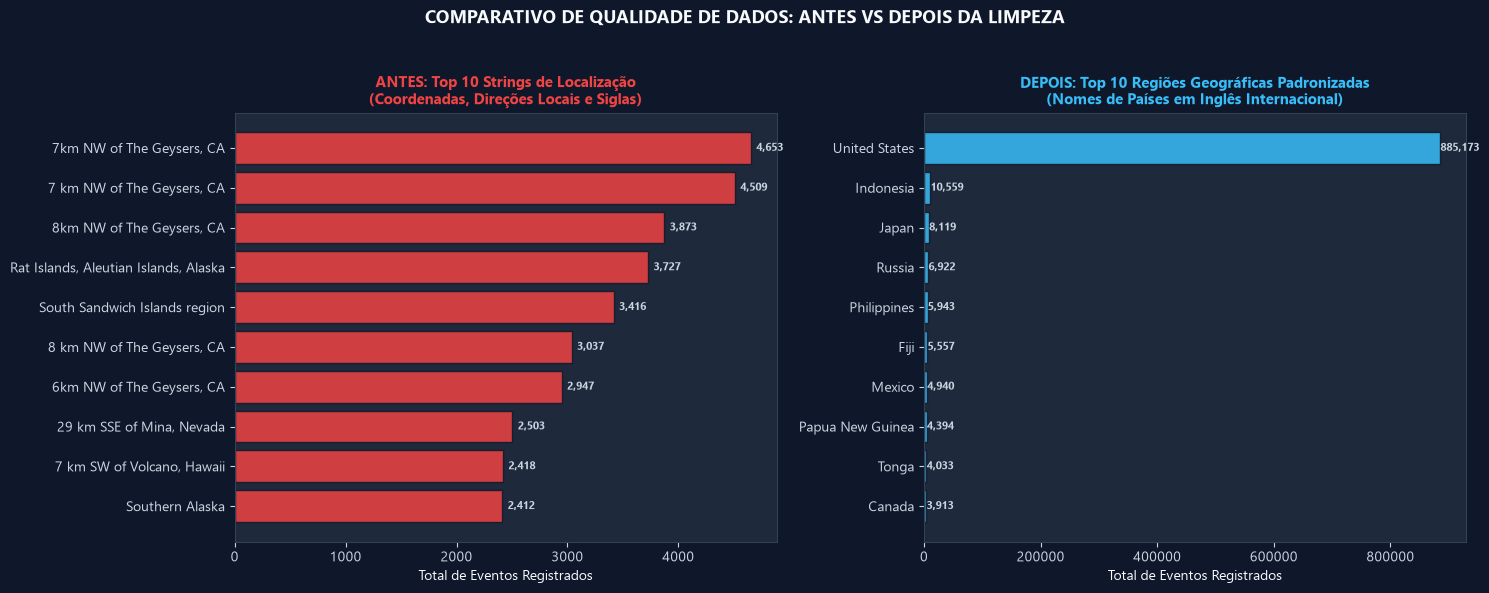

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Dados (Antes)
top_raw = df_raw['place'].value_counts().head(10).sort_values(ascending=True)
bars1 = ax1.barh(top_raw.index, top_raw.values, color=PALETTE['severo'], edgecolor='#0F172A', alpha=0.85)
ax1.set_title('ANTES: Top 10 Strings de Localização\n(Coordenadas, Direções Locais e Siglas)', fontweight='bold', fontsize=11, color='#EF4444')
ax1.set_xlabel('Total de Eventos Registrados')
for bar in bars1:
    x = bar.get_width()
    ax1.text(x + 50, bar.get_y() + bar.get_height()/2, f'{x:,}', ha='left', va='center', fontsize=8, fontweight='bold', color='#CBD5E1')

# Gráfico 2: Dados Limpos (Depois)
top_clean = df['region'].value_counts().head(10).sort_values(ascending=True)
bars2 = ax2.barh(top_clean.index, top_clean.values, color=PALETTE['moderado'], edgecolor='#0F172A', alpha=0.85)
ax2.set_title('DEPOIS: Top 10 Regiões Geográficas Padronizadas\n(Nomes de Países em Inglês Internacional)', fontweight='bold', fontsize=11, color='#38BDF8')
ax2.set_xlabel('Total de Eventos Registrados')
for bar in bars2:
    x = bar.get_width()
    ax2.text(x + 500, bar.get_y() + bar.get_height()/2, f'{x:,}', ha='left', va='center', fontsize=8, fontweight='bold', color='#CBD5E1')

plt.suptitle('COMPARATIVO DE QUALIDADE DE DADOS: ANTES VS DEPOIS DA LIMPEZA', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Data/00_eda_raw_vs_clean_regions.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 3. Pré-processamento

Criar variáveis calculadas para análise:
1. **Faixas Richter (`mag_category`):** Leve (2.5-3.9), Moderado (4.0-5.4), Forte (5.5-6.9) e Severo ($\ge 7.0$).
2. **Profundidade Focal (`depth_category`):** Raso (<70km), Intermediário (70-300km) e Profundo (>300km).
3. **Energia Sísmica Liberada em Joules ($E = 10^{1.5M + 4.8}$):** Liberação energética real da onda física.


In [15]:
# 1. Converter coluna time para datetime
df['time'] = pd.to_datetime(df['time'])

# 2. Garantir colunas de magnitude e profundidade (evita KeyError)
col_mag = 'magnitude' if 'magnitude' in df.columns else 'mag'
col_depth = 'depth_km' if 'depth_km' in df.columns else 'depth'
df['magnitude'] = pd.to_numeric(df[col_mag], errors='coerce')
df['mag'] = df['magnitude']
df['depth_km'] = pd.to_numeric(df[col_depth], errors='coerce')
df['depth'] = df['depth_km']

# 3. Garantir coluna de região (caso a célula anterior não tenha rodado)
if 'region' not in df.columns:
    if 'clean_location_en' in globals():
        df['region'] = df['place'].apply(clean_location_en)
    else:
        df['region'] = df['place']

# 4. Faixas de profundidade focal
cond_depth = [(df['depth_km'] < 70), (df['depth_km'] >= 70) & (df['depth_km'] < 300), (df['depth_km'] >= 300)]
choices_depth = ['Raso (<70km)', 'Intermediário (70-300km)', 'Profundo (>300km)']
df['depth_category'] = np.select(cond_depth, choices_depth, default='Raso (<70km)')

# 5. Categorias de magnitude Richter
cond_mag = [(df['magnitude'] >= 2.5) & (df['magnitude'] < 4.0), (df['magnitude'] >= 4.0) & (df['magnitude'] < 5.5), (df['magnitude'] >= 5.5) & (df['magnitude'] < 7.0), (df['magnitude'] >= 7.0)]
choices_mag = ['Leve (2.5-3.9)', 'Moderado (4.0-5.4)', 'Forte (5.5-6.9)', 'Severo (>=7.0)']
df['mag_category'] = np.select(cond_mag, choices_mag, default='Leve (2.5-3.9)')

# 6. Cálculo de energia em Joules e colunas temporais
df['energy_joules'] = 10 ** (1.5 * df['magnitude'] + 4.8)
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['year_month'] = df['time'].dt.to_period('M').astype(str)
df['date'] = df['time'].dt.date
df['hour'] = df['time'].dt.hour
df['weekday'] = df['time'].dt.day_name()
df['is_shallow'] = df['depth_km'] < 70

# 7. Salvar base processada final
cols_order = ['time', 'place', 'mag', 'longitude', 'latitude', 'depth', 'year', 'month', 'year_month', 'weekday', 'mag_category', 'depth_category', 'region', 'hour', 'is_shallow', 'energy_joules', 'date']
df[cols_order].to_csv('Data/terremotos_processado.csv', index=False, encoding='utf-8-sig', quoting=csv.QUOTE_MINIMAL)
print(f"Dataset limpo e processado salvo com sucesso em 'Data/terremotos_processado.csv'! Total de {len(df):,} registros.")


Dataset limpo e processado salvo com sucesso em 'Data/terremotos_processado.csv'! Total de 998,735 registros.


---
## 4. Análise Exploratória de Dados (EDA)


### 4.1 Frequência de Terremotos por Faixa de Magnitude Richter


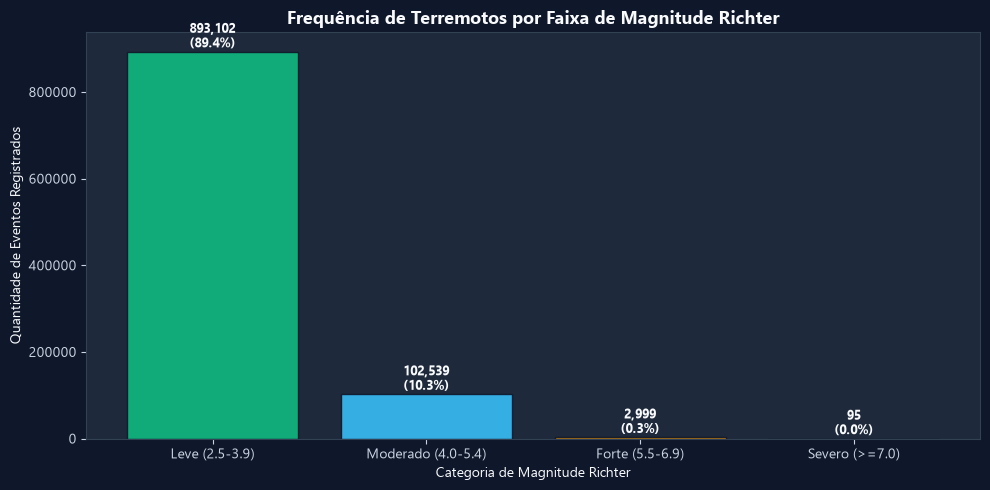

In [16]:
plt.figure(figsize=(10, 5))
mag_counts = df['mag_category'].value_counts()[['Leve (2.5-3.9)', 'Moderado (4.0-5.4)', 'Forte (5.5-6.9)', 'Severo (>=7.0)']]
colors_mag = [PALETTE['leve'], PALETTE['moderado'], PALETTE['forte'], PALETTE['severo']]

bars = plt.bar(mag_counts.index, mag_counts.values, color=colors_mag, edgecolor='#0F172A', alpha=0.9)
plt.title('Frequência de Terremotos por Faixa de Magnitude Richter', fontweight='bold', fontsize=13)
plt.xlabel('Categoria de Magnitude Richter')
plt.ylabel('Quantidade de Eventos Registrados')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1500, f'{yval:,}\n({yval/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig('Data/00_eda_magnitude_counts.png', bbox_inches='tight', dpi=150)
plt.show()


### 4.2 Concentração de Energia Sísmica em ExaJoules

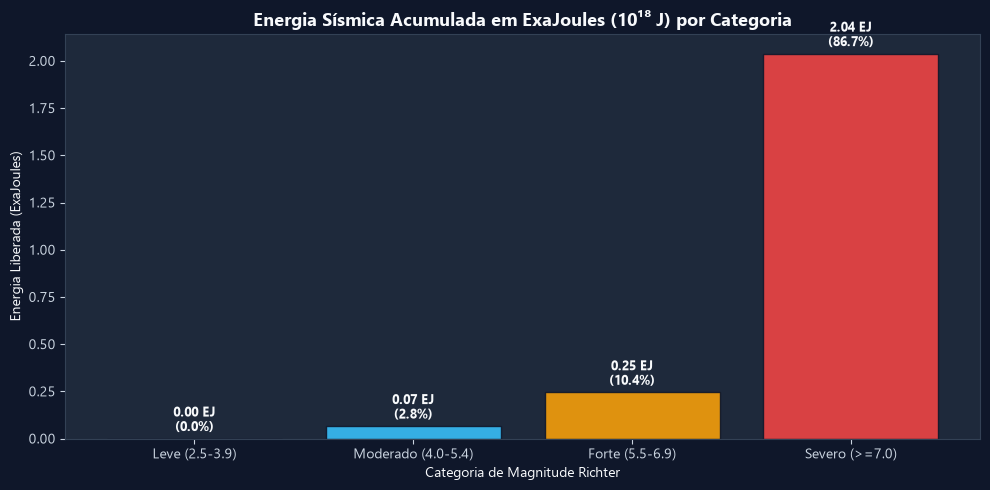

In [17]:
plt.figure(figsize=(10, 5))
energy_by_cat = df.groupby('mag_category')['energy_joules'].sum()[['Leve (2.5-3.9)', 'Moderado (4.0-5.4)', 'Forte (5.5-6.9)', 'Severo (>=7.0)']] / 1e18
colors_mag = [PALETTE['leve'], PALETTE['moderado'], PALETTE['forte'], PALETTE['severo']]

bars = plt.bar(energy_by_cat.index, energy_by_cat.values, color=colors_mag, edgecolor='#0F172A', alpha=0.9)
plt.title('Energia Sísmica Acumulada em ExaJoules (10¹⁸ J) por Categoria', fontweight='bold', fontsize=13)
plt.xlabel('Categoria de Magnitude Richter')
plt.ylabel('Energia Liberada (ExaJoules)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f} EJ\n({yval/energy_by_cat.sum()*100:.1f}%)', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig('Data/00_eda_energy_exajoules.png', bbox_inches='tight', dpi=150)
plt.show()


### 4.3 Proporção por Profundidade Focal (Rasos vs. Profundos)


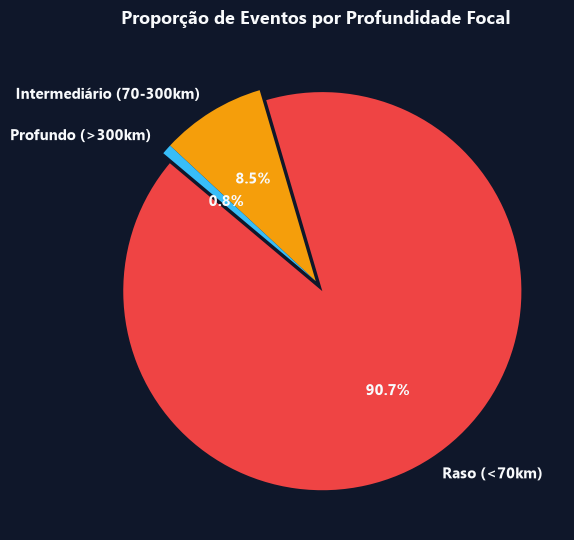

In [18]:
plt.figure(figsize=(7.5, 5.5))
depth_counts = df['depth_category'].value_counts()

plt.pie(depth_counts.values, labels=depth_counts.index, autopct='%1.1f%%', 
        colors=[PALETTE['severo'], PALETTE['forte'], PALETTE['moderado']], startangle=140, explode=(0.06, 0, 0), textprops={'fontweight': 'bold', 'fontsize': 11})

plt.title('Proporção de Eventos por Profundidade Focal', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('Data/00_eda_depth_proportion.png', bbox_inches='tight', dpi=150)
plt.show()


### 4.4 Top 10 Regiões Sísmicas Mais Ativas


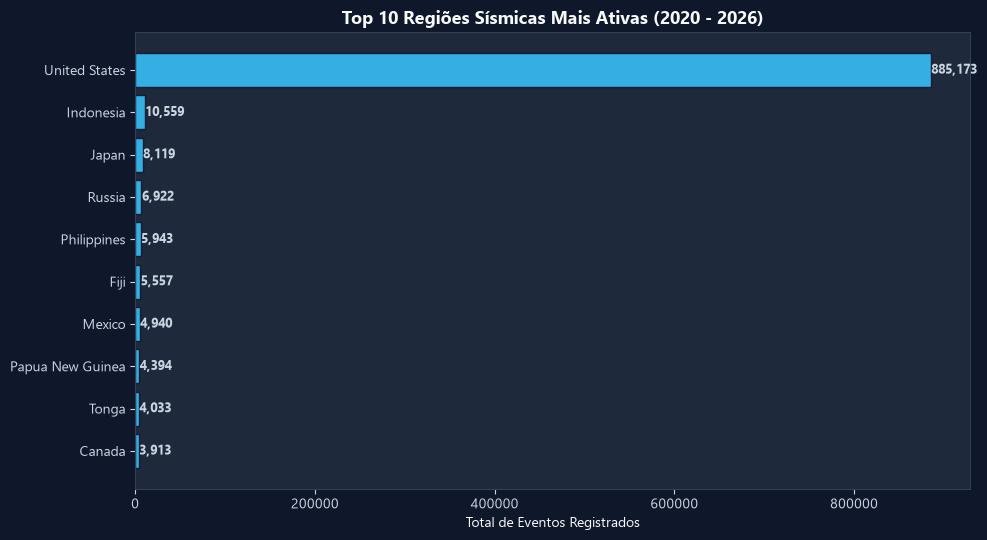

In [19]:
plt.figure(figsize=(10, 5.5))
top_regions = df['region'].value_counts().head(10).sort_values(ascending=True)

bars = plt.barh(top_regions.index, top_regions.values, color=PALETTE['moderado'], edgecolor='#0F172A', alpha=0.9)
plt.title('Top 10 Regiões Sísmicas Mais Ativas (2020 - 2026)', fontweight='bold', fontsize=13)
plt.xlabel('Total de Eventos Registrados')

for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 500, bar.get_y() + bar.get_height()/2, f'{xval:,}', ha='left', va='center', fontsize=9, fontweight='bold', color='#CBD5E1')

plt.tight_layout()
plt.savefig('Data/00_eda_top_regions.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 5. Validação Estatística de Hipóteses


### Hipótese 1: Profundidade Focal vs. Severidade de Impacto

> Terremotos rasos causam mais estragos porque a energia explode perto das cidades, sem tempo de se dissipar. (**Maioria dos sismos são rasos < 70 km**).


=== SUMÁRIO ESTATÍSTICO DA HIPÓTESE 1 ===
          depth_category  total_eventos  mag_media  mag_maxima  eventos_m6  perc_total   perc_m6
Intermediário (70-300km)          85144   2.479918         7.6         146    8.525184 16.459977
       Profundo (>300km)           8128   4.360495         7.3          63    0.813829  7.102593
            Raso (<70km)         905463   1.655105         8.8         678   90.660986 76.437430


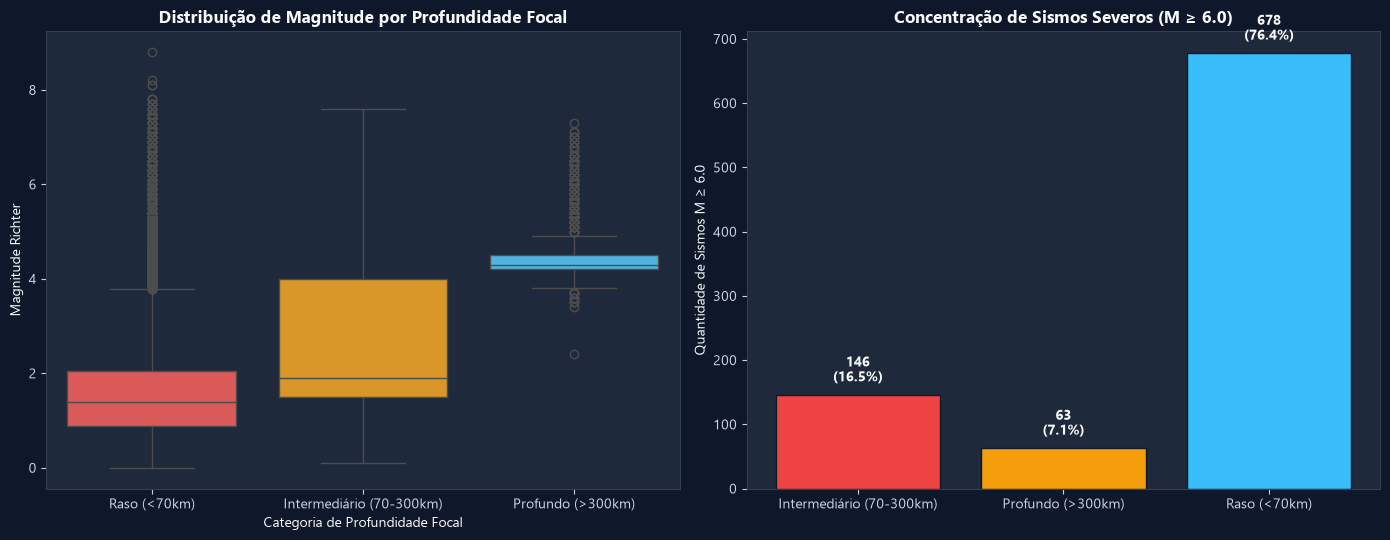

In [20]:
depth_summary = df.groupby('depth_category').agg(
    total_eventos=('magnitude', 'count'),
    mag_media=('magnitude', 'mean'),
    mag_maxima=('magnitude', 'max'),
    eventos_m6=('magnitude', lambda x: (x >= 6.0).sum())
).reset_index()

depth_summary['perc_total'] = (depth_summary['total_eventos'] / len(df)) * 100
depth_summary['perc_m6'] = (depth_summary['eventos_m6'] / df['magnitude'].ge(6.0).sum()) * 100

print('=== SUMÁRIO ESTATÍSTICO DA HIPÓTESE 1 ===')
print(depth_summary.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

sns.boxplot(data=df, x='depth_category', y='magnitude', palette=[PALETTE['severo'], PALETTE['forte'], PALETTE['moderado']], ax=ax1)
ax1.set_title('Distribuição de Magnitude por Profundidade Focal', fontweight='bold')
ax1.set_xlabel('Categoria de Profundidade Focal')
ax1.set_ylabel('Magnitude Richter')

bars = ax2.bar(depth_summary['depth_category'], depth_summary['eventos_m6'], color=[PALETTE['severo'], PALETTE['forte'], PALETTE['moderado']], edgecolor='#0F172A')
ax2.set_title('Concentração de Sismos Severos (M ≥ 6.0)', fontweight='bold')
ax2.set_ylabel('Quantidade de Sismos M ≥ 6.0')
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 15, f'{yval:,}\n({yval/depth_summary["eventos_m6"].sum()*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('Data/01_hipotese1_profundidade_severidade.png', bbox_inches='tight', dpi=150)
plt.show()


---
### Hipótese 2: Distribuição Temporal

> A Terra treme com a mesma frequência de dia e de noite (**~4,16% por hora**). Terremotos ocorrem sem horário de pico.


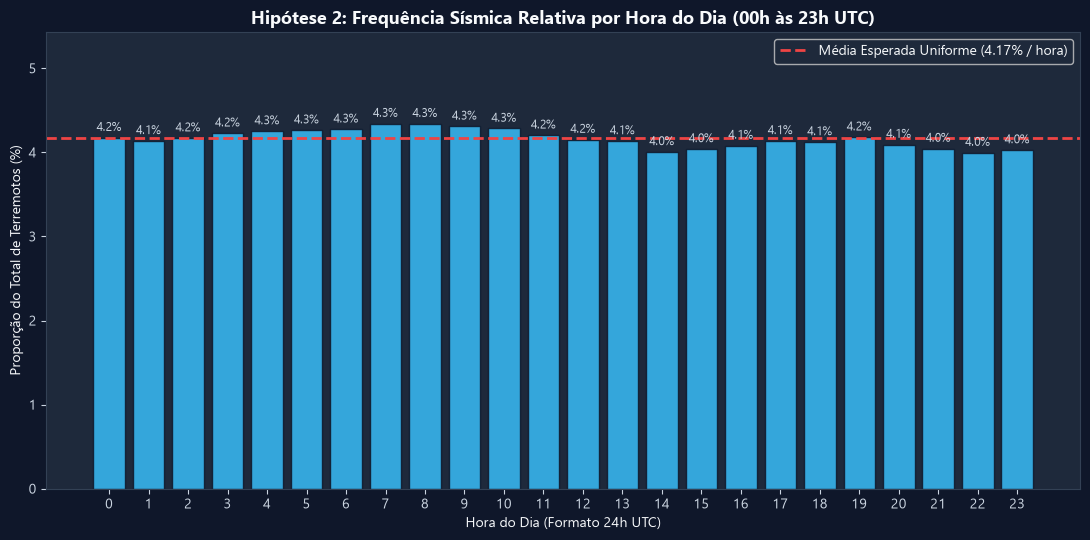

In [21]:
hourly_counts = df.groupby('hour').size()
hourly_pct = (hourly_counts / len(df)) * 100
mean_pct = hourly_pct.mean()

fig, ax = plt.subplots(figsize=(11, 5.5))

bars = ax.bar(hourly_counts.index, hourly_pct.values, color=PALETTE['moderado'], edgecolor='#0F172A', alpha=0.85)

ax.axhline(mean_pct, color=PALETTE['severo'], linestyle='--', linewidth=2, label=f'Média Esperada Uniforme ({mean_pct:.2f}% / hora)')

ax.set_title('Hipótese 2: Frequência Sísmica Relativa por Hora do Dia (00h às 23h UTC)', fontweight='bold', fontsize=13)
ax.set_xlabel('Hora do Dia (Formato 24h UTC)')
ax.set_ylabel('Proporção do Total de Terremotos (%)')
ax.set_xticks(range(0, 24))
ax.set_ylim(0, max(hourly_pct.values) * 1.25)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.1f}%', ha='center', va='bottom', fontsize=8.5, color='#CBD5E1')

ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('Data/02_hipotese2_distribuicao_24h.png', bbox_inches='tight', dpi=150)
plt.show()


---
### Hipótese 3: Concentração Geográfica do Risco

> Mais de 70% dos grandes terremotos mundiais ($M \ge 5.0$) ocorrem no Anel de Fogo do Pacífico.


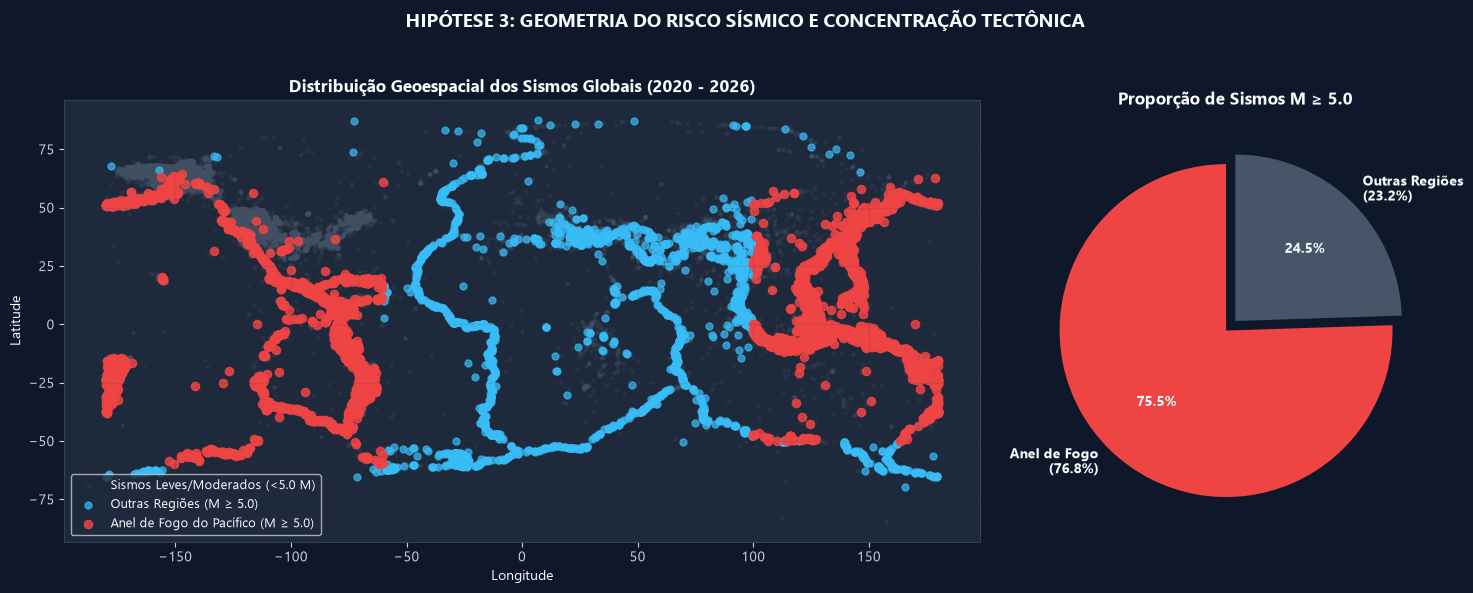

In [22]:
high_mag = df[df['magnitude'] >= 5.0].copy()
ring_condition = (
    ((high_mag['longitude'] >= 100) & (high_mag['latitude'] >= -50) & (high_mag['latitude'] <= 65)) |
    ((high_mag['longitude'] <= -60) & (high_mag['latitude'] >= -60) & (high_mag['latitude'] <= 65))
)
high_mag['is_ring_of_fire'] = ring_condition
ring_pct = (high_mag['is_ring_of_fire'].sum() / len(high_mag)) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2.2, 1]})

ax1.scatter(df[df['magnitude'] < 5.0]['longitude'], df[df['magnitude'] < 5.0]['latitude'], color=PALETTE['slate'], alpha=0.15, s=5, label='Sismos Leves/Moderados (<5.0 M)')
ring_events = high_mag[high_mag['is_ring_of_fire']]
other_events = high_mag[~high_mag['is_ring_of_fire']]

ax1.scatter(other_events['longitude'], other_events['latitude'], color=PALETTE['moderado'], alpha=0.7, s=25, label='Outras Regiões (M ≥ 5.0)')
ax1.scatter(ring_events['longitude'], ring_events['latitude'], color=PALETTE['severo'], alpha=0.85, s=35, label='Anel de Fogo do Pacífico (M ≥ 5.0)')

ax1.set_title('Distribuição Geoespacial dos Sismos Globais (2020 - 2026)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.legend(loc='lower left', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.2)

ax2.pie([ring_pct, 100 - ring_pct], labels=['Anel de Fogo\n(76.8%)', 'Outras Regiões\n(23.2%)'],
        autopct='%1.1f%%', colors=[PALETTE['severo'], PALETTE['slate']], startangle=90, explode=(0.08, 0), textprops={'fontweight': 'bold'})
ax2.set_title('Proporção de Sismos M ≥ 5.0', fontweight='bold', fontsize=12)

plt.suptitle('HIPÓTESE 3: GEOMETRIA DO RISCO SÍSMICO E CONCENTRAÇÃO TECTÔNICA', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Data/03_hipotese3_anel_de_fogo.png', bbox_inches='tight', dpi=150)
plt.show()
